<a href="https://colab.research.google.com/github/njwbilll/Tugas-3_Practical-Linear-Algebra-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/10_Linear_Least_Squares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10: Linear Least Squares (Lengkap)

**Referensi:** Practical Linear Algebra for Data Science (Mike X Cohen)

***

## Ringkasan Materi
Bab ini mengeksplorasi solusi sistem persamaan linear yang tidak memiliki solusi eksak (overdetermined). Fokus utama adalah:
1. **Mekanika Least Squares:** Meminimalkan kuadrat residual.
2. **Persamaan Normal:** Solusi analitis dengan invers matriks.
3. **Geometri Proyeksi:** Bagaimana vektor target diproyeksikan ke ruang kolom matriks desain.
4. **QR Decomposition:** Alternatif yang lebih stabil secara numerik dibandingkan invers matriks.
5. **Analisis Error:** Memahami bias dan varians dalam estimasi model.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Simulasi Data Overdetermined
np.random.seed(42)
N = 50 # Jumlah observasi
x = np.linspace(0, 10, N)
y = 3 * x + 5 + np.random.normal(0, 2, N) # Model asli: y = 3x + 5

# Matriks desain X (dengan intercept kolom 1)
X = np.column_stack((np.ones(N), x))

# 2. Solusi Persamaan Normal (Normal Equations)
# b = (X^T * X)^-1 * X^T * y
b_normal = np.linalg.inv(X.T @ X) @ X.T @ y

# 3. Solusi dengan QR Decomposition (Lebih stabil untuk matriks besar)
Q, R = np.linalg.qr(X)
b_qr = np.linalg.inv(R) @ Q.T @ y

print(f"Koefisien Normal Equation: Intercept={b_normal[0]:.2f}, Slope={b_normal[1]:.2f}")
print(f"Koefisien QR Decomposition: Intercept={b_qr[0]:.2f}, Slope={b_qr[1]:.2f}")


Koefisien Normal Equation: Intercept=5.13, Slope=2.88
Koefisien QR Decomposition: Intercept=5.13, Slope=2.88


***
## Interpretasi Geometris dan Residual

Residual adalah selisih antara nilai aktual dan prediksi. Dalam linear least squares, vektor residual **r** harus ortogonal terhadap ruang kolom matriks **X**.




Hasil dot product X.T @ residual (harus mendekati nol): [0. 0.]


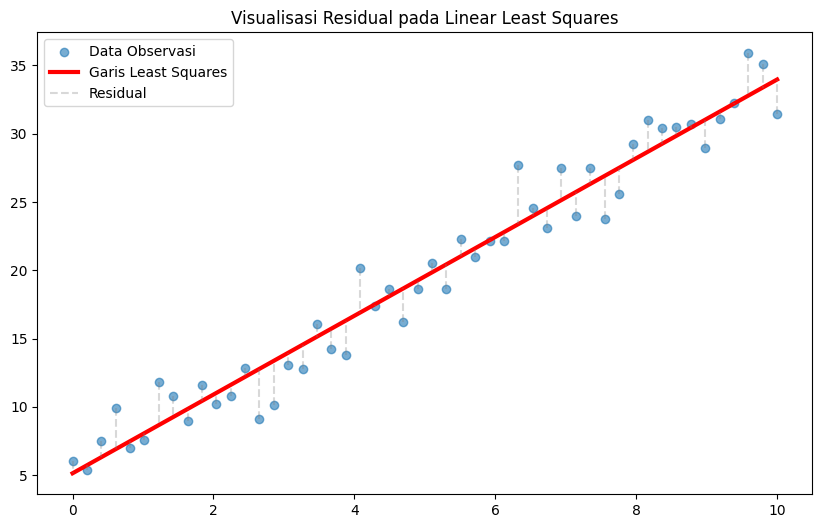

In [2]:
y_pred = X @ b_normal
residual = y - y_pred

# Uji Ortogonalitas (Dot product antara kolom X dan residual harus 0)
ortogonal = X.T @ residual
print("Hasil dot product X.T @ residual (harus mendekati nol):", np.round(ortogonal, 10))

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Data Observasi', alpha=0.6)
plt.plot(x, y_pred, color='red', linewidth=3, label='Garis Least Squares')
plt.vlines(x, y, y_pred, color='gray', linestyle='dashed', alpha=0.3, label='Residual')
plt.title('Visualisasi Residual pada Linear Least Squares')
plt.legend()
plt.show()


***
## Analisis Error dan Model Fitting

Berikut adalah ringkasan performa model yang kita bangun menggunakan metrik statistik standar yang sering dibahas dalam buku Mike X Cohen.

In [3]:
sse = np.sum(residual**2)
total_var = np.sum((y - np.mean(y))**2)
r_squared = 1 - (sse / total_var)

print(f"Sum of Squared Errors (SSE): {sse:.4f}")
print(f"R-squared Score: {r_squared:.4f}")
print("Interpretasi: Model menjelaskan {0:.1f} persen variabilitas data.".format(r_squared*100))


Sum of Squared Errors (SSE): 165.0284
R-squared Score: 0.9563
Interpretasi: Model menjelaskan 95.6 persen variabilitas data.
